In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../dataset/Loan_Default_Clean_Balanced_5050.csv")

In [3]:
df.head()

,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,loan_amount,rate_of_interest,...,income,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Status,dtir1
0,cf,Sex Not Available,nopre,type1,p3,l1,nopc,nob/c,526500,3.99,...,11580.0,EXP,796,CIB,35-44,to_inst,78.817365,south,0,22.0
1,NaN,Sex Not Available,nopre,type1,p4,l1,nopc,nob/c,396500,NaN,...,4260.0,EQUI,854,EXP,45-54,to_inst,NaN,south,1,NaN
2,cf,Male,nopre,type2,p4,l1,nopc,b/c,506500,NaN,...,0.0,EQUI,803,EXP,55-64,to_inst,NaN,south,1,NaN
3,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,56500,NaN,...,960.0,EQUI,714,EXP,25-34,to_inst,NaN,south,1,NaN
4,cf,Female,nopre,type1,p1,l2,nopc,nob/c,166500,NaN,...,2340.0,EQUI,525,EXP,>74,to_inst,NaN,North,1,NaN


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73278 entries, 0 to 73277
Data columns (total 29 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   loan_limit                 71590 non-null  object 
 1   Gender                     73278 non-null  object 
 2   approv_in_adv              72831 non-null  object 
 3   loan_type                  73278 non-null  object 
 4   loan_purpose               73208 non-null  object 
 5   Credit_Worthiness          73278 non-null  object 
 6   open_credit                73278 non-null  object 
 7   business_or_commercial     73278 non-null  object 
 8   loan_amount                73278 non-null  int64  
 9   rate_of_interest           36839 non-null  float64
 10  Interest_rate_spread       36639 non-null  float64
 11  Upfront_charges            35743 non-null  float64
 12  term                       73255 non-null  float64
 13  Neg_ammortization          73215 non-null  obj

In [6]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
loan_amount,73278.0,327589.139987,193358.388504,16500.000000,186500.000000,286500.000000,426500.000000,3.576500e+06
rate_of_interest,36839.0,4.044525,0.561846,0.000000,3.625000,3.990000,4.375000,7.750000e+00
Interest_rate_spread,36639.0,0.442311,0.516319,-3.638000,0.073400,0.392600,0.781400,2.885400e+00
Upfront_charges,35743.0,3228.414906,3241.041428,0.000000,550.000000,2599.440000,4836.285000,3.843750e+04
term,73255.0,335.111829,58.030355,96.000000,360.000000,360.000000,360.000000,3.600000e+02
property_value,58182.0,489140.215187,384523.556383,8000.000000,258000.000000,398000.000000,608000.000000,1.650800e+07
income,69379.0,6702.829963,6777.121528,0.000000,3480.000000,5460.000000,8220.000000,5.785800e+05
Credit_Score,73278.0,700.135702,116.252429,500.000000,599.000000,700.000000,802.000000,9.000000e+02
LTV,58182.0,73.807694,52.585825,0.967478,61.246787,76.162791,87.613982,7.831250e+03
Status,73278.0,0.500000,0.500003,0.000000,0.000000,0.500000,1.000000,1.000000e+00


In [7]:
df.isnull().sum()

loan_limit                    1688
Gender                           0
approv_in_adv                  447
loan_type                        0
loan_purpose                    70
Credit_Worthiness                0
open_credit                      0
business_or_commercial           0
loan_amount                      0
rate_of_interest             36439
Interest_rate_spread         36639
Upfront_charges              37535
term                            23
Neg_ammortization               63
interest_only                    0
lump_sum_payment                 0
property_value               15096
occupancy_type                   0
total_units                      0
income                        3899
credit_type                      0
Credit_Score                     0
co-applicant_credit_type         0
age                            200
submission_of_application      200
LTV                          15096
Region                           0
Status                           0
dtir1               

C:\Users\krish\AppData\Local\Temp\ipykernel_7972\2616895368.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Status', data=df, palette=['#87CEEB', '#FFD700'], ax=ax)


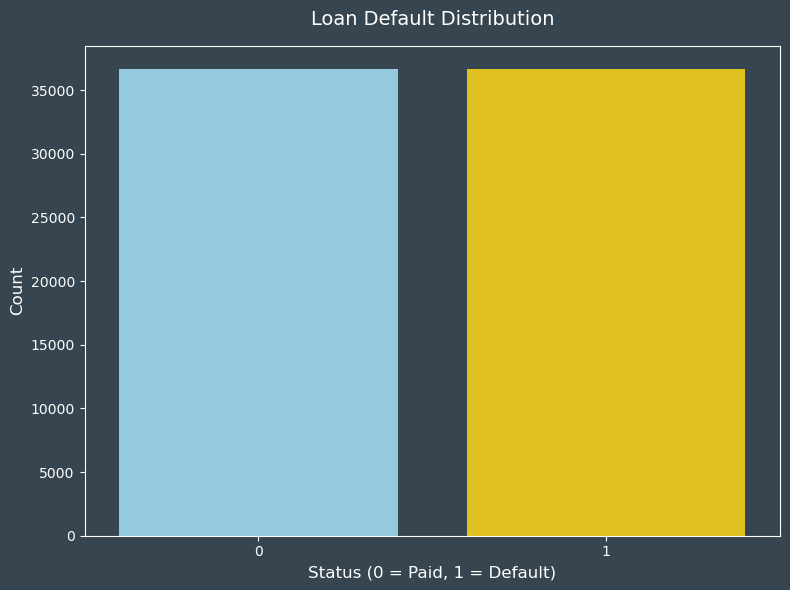

In [11]:
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor('#36454F') # Charcoal background
ax.set_facecolor('#36454F')

sns.countplot(x='Status', data=df, palette=['#87CEEB', '#FFD700'], ax=ax)

plt.title('Loan Default Distribution', color='white', fontsize=14, pad=15)
plt.xlabel('Status (0 = Paid, 1 = Default)', color='white', fontsize=12)
plt.ylabel('Count', color='white', fontsize=12)

plt.tight_layout()
plt.savefig('../reports/target_distribution_1.png', facecolor=fig.get_facecolor(), edgecolor='none')
plt.show()

In [12]:
print(df.select_dtypes(include=['int64', 'float64']).columns.tolist())

['loan_amount', 'rate_of_interest', 'Interest_rate_spread', 'Upfront_charges', 'term', 'property_value', 'income', 'Credit_Score', 'LTV', 'Status', 'dtir1']


In [13]:
numeric_cols = [
    'loan_amount', 'income', 'property_value', 
    'Credit_Score', 'LTV', 'dtir1', 
    'term', 'Upfront_charges', 'rate_of_interest'
]

<Figure size 2560x1920 with 0 Axes>

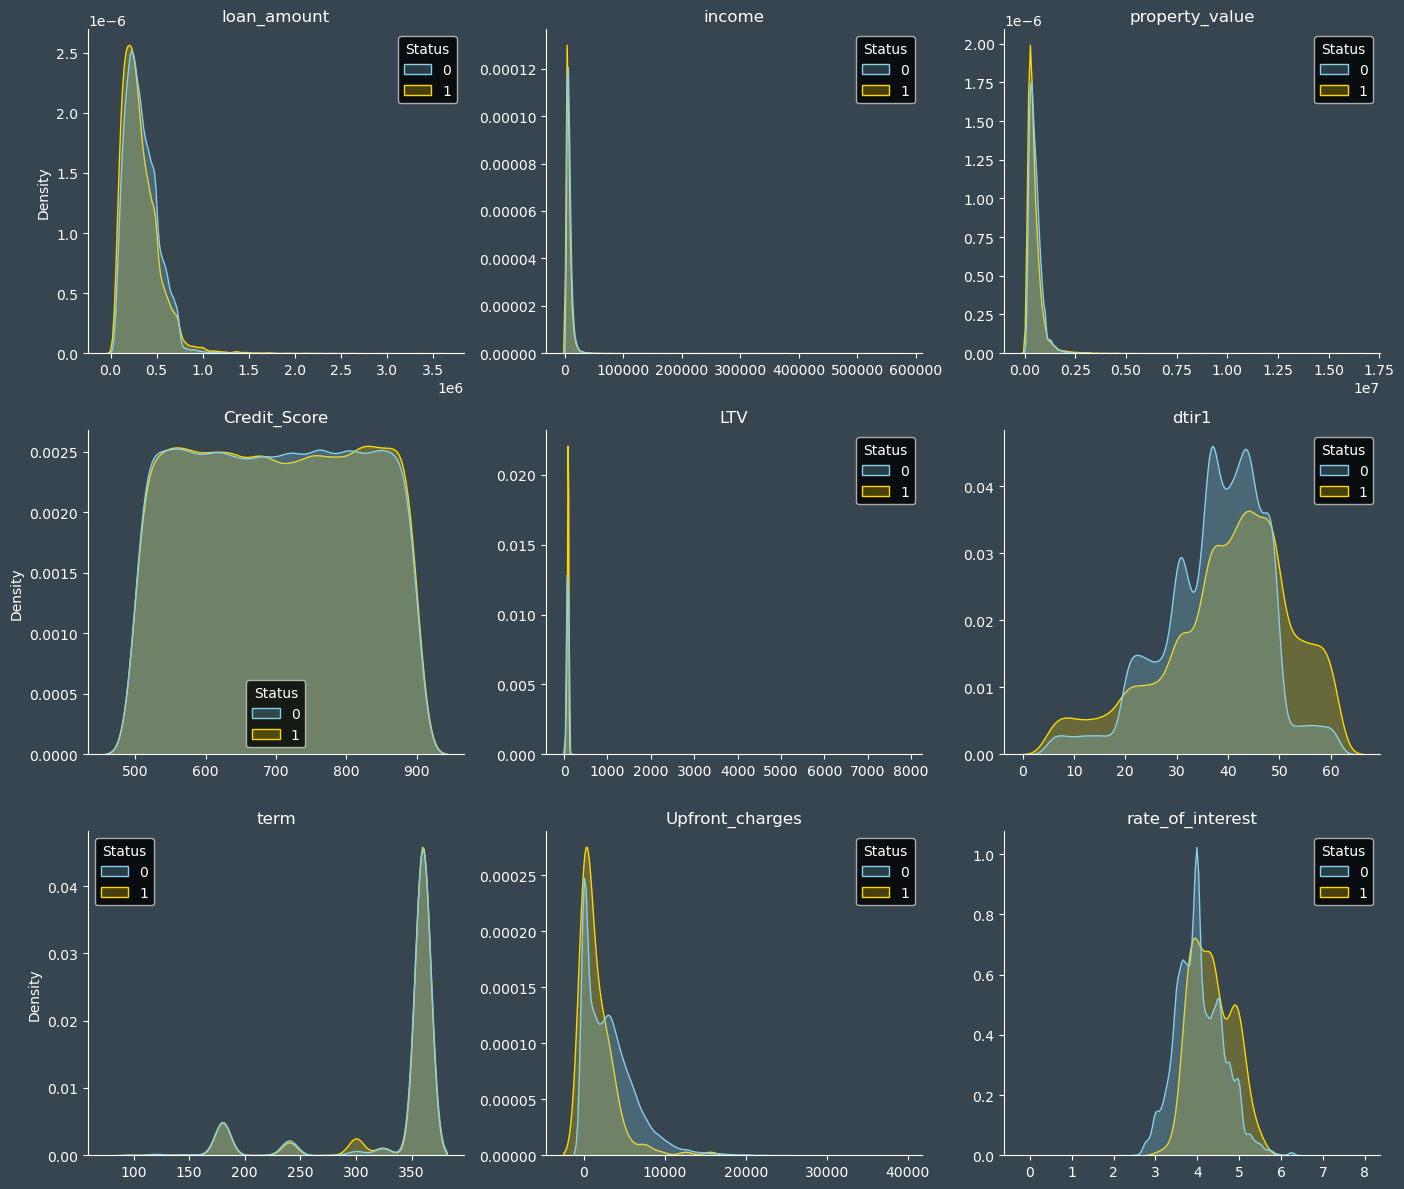

In [14]:
plt.style.use('dark_background')
fit = plt.figure(dpi=400)
fig, axes = plt.subplots(3, 3, figsize=(14, 12))
fig.patch.set_facecolor('#36454F')

for i, col in enumerate(numeric_cols):
    ax = axes[i // 3, i % 3]
    ax.set_facecolor('#36454F')
    sns.kdeplot(
        data=df, 
        x=col, 
        hue='Status', 
        ax=ax, 
        fill=True, 
        common_norm=False, 
        palette=['#87CEEB', '#FFD700'],
        warn_singular=False
    )
    ax.set_title(col, color='white')
    ax.set_xlabel('')
    ax.set_ylabel('Density' if i % 3 == 0 else '')
    ax.tick_params(colors='white')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../reports/target_distribution_2.png', facecolor=fig.get_facecolor(), edgecolor='none')
plt.show()

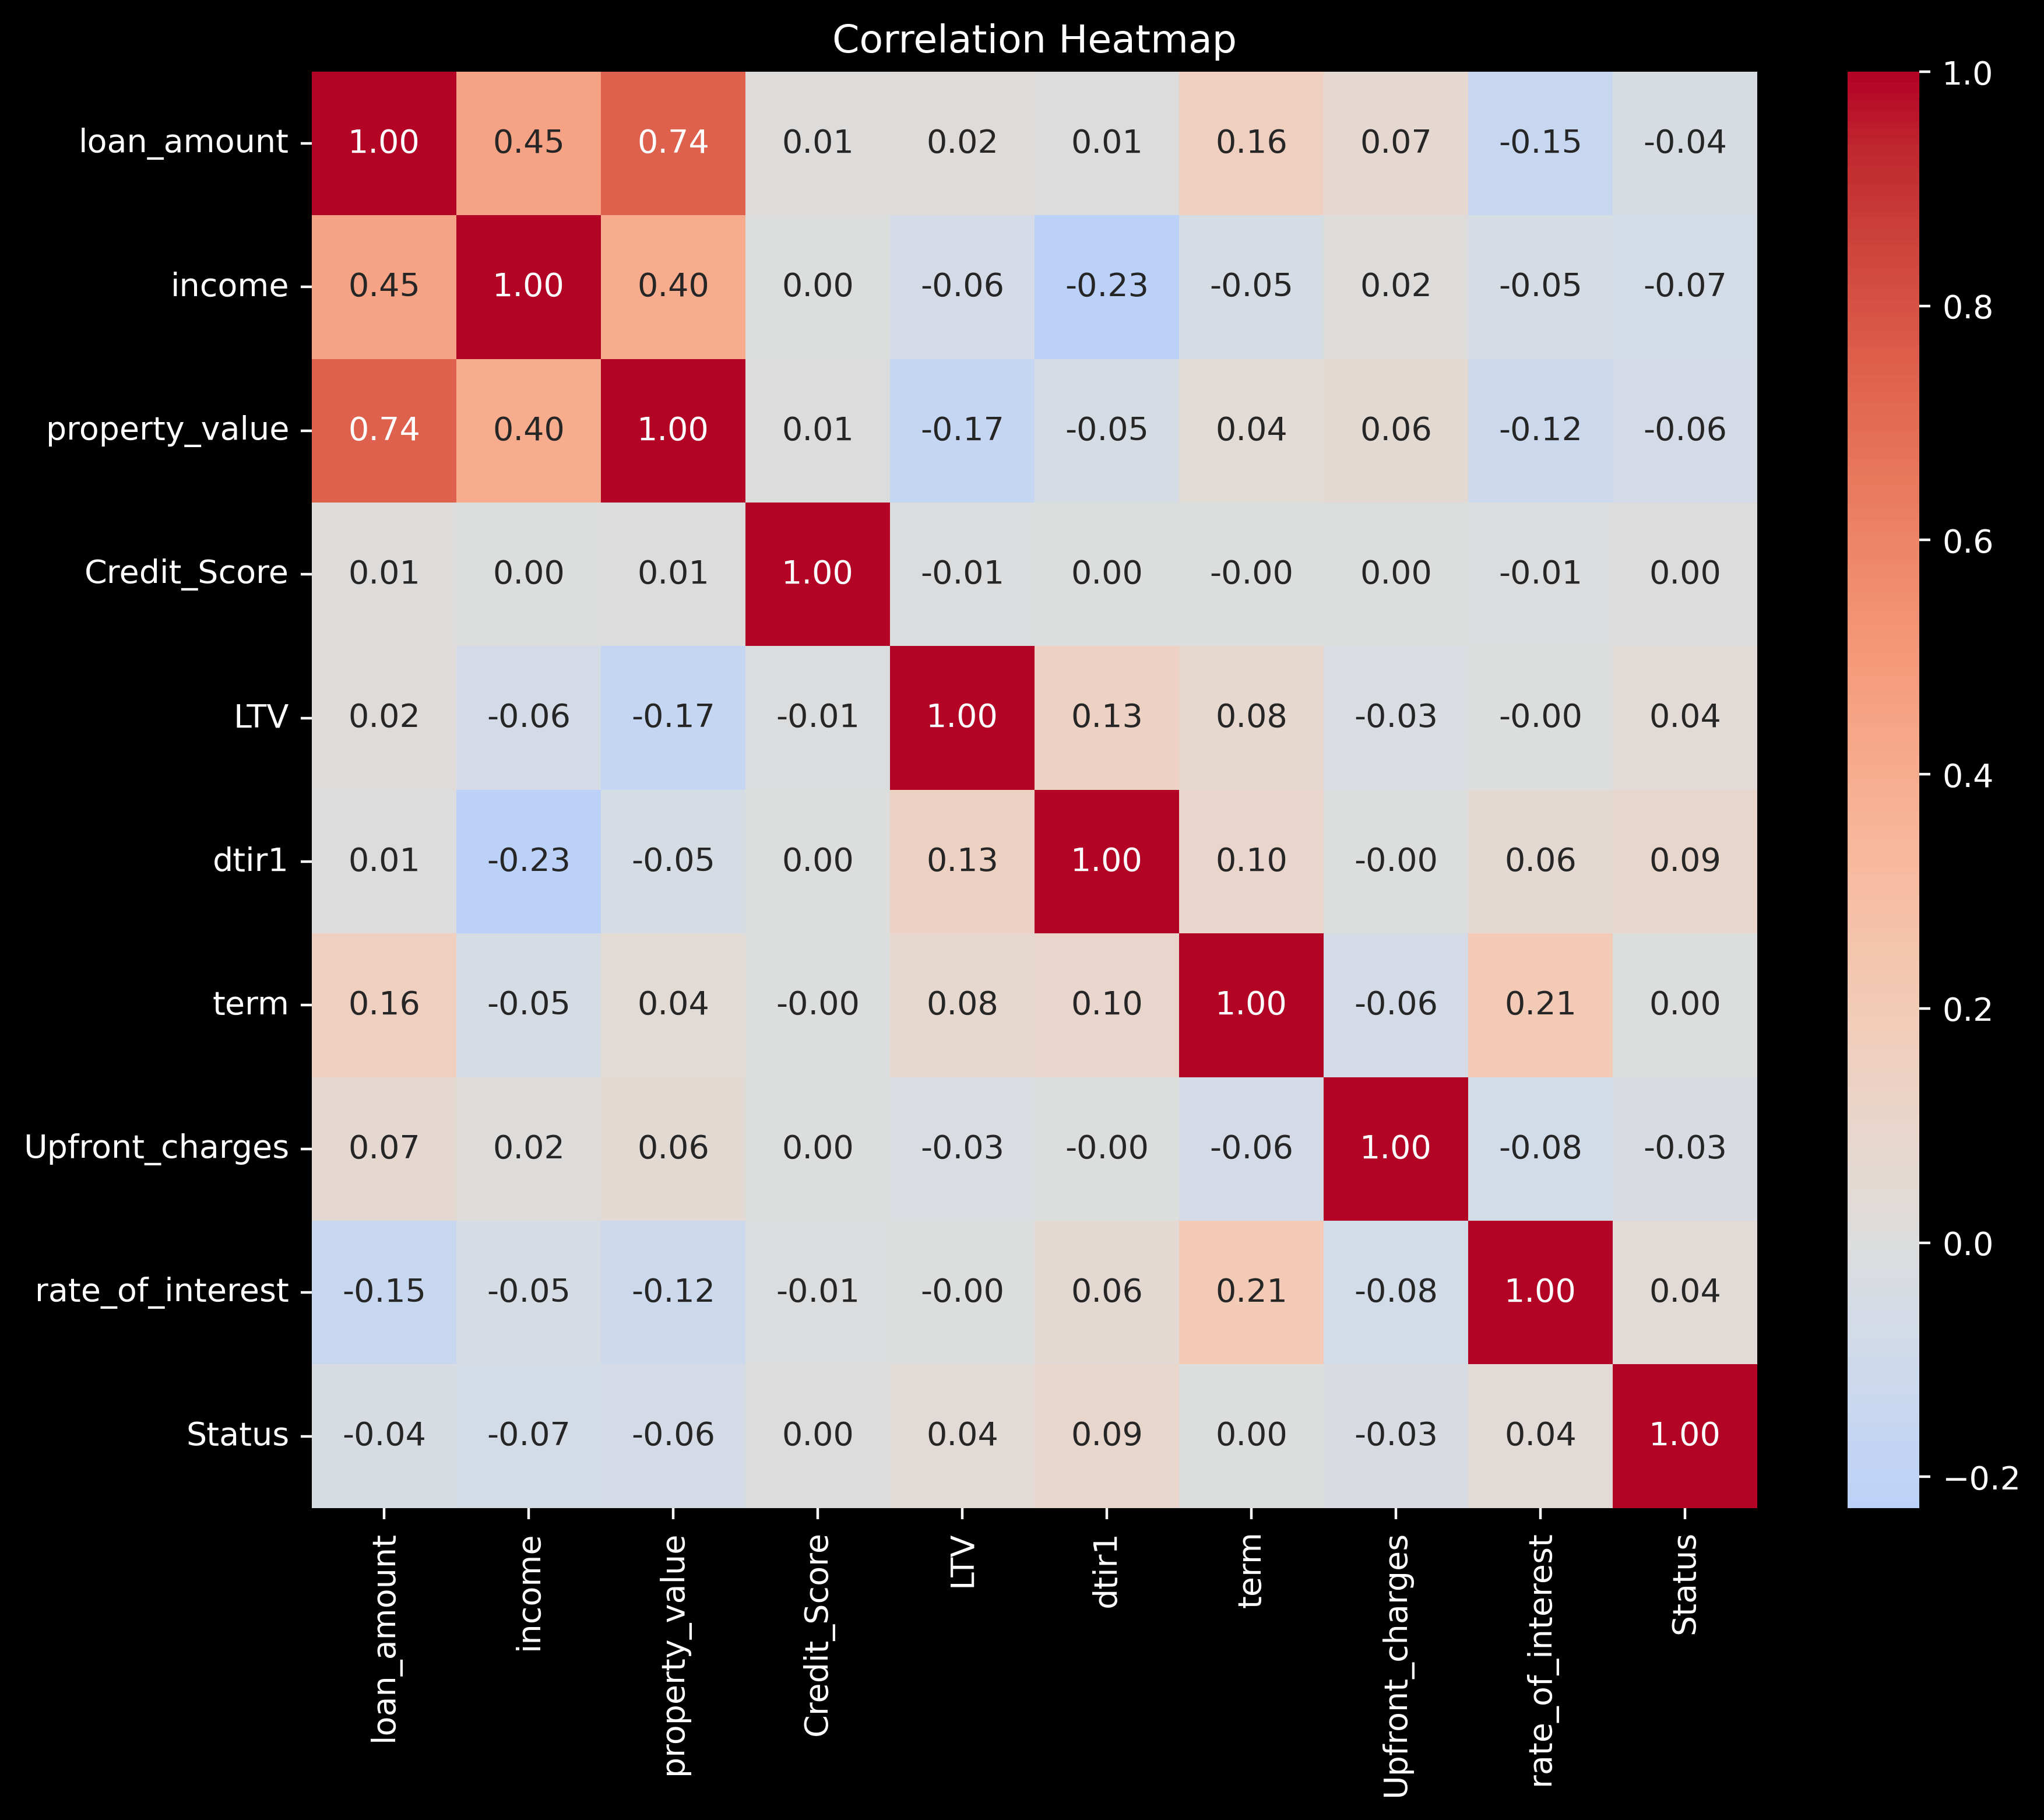

In [15]:
plt.figure(figsize=(10, 8), dpi=400)
corr = df[numeric_cols + ['Status']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Heatmap')
plt.savefig('../reports/target_distribution_3.png')
plt.show()

C:\Users\krish\AppData\Local\Temp\ipykernel_7972\3340601835.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Status', y=col, data=df, ax=ax, palette=['#87CEEB', '#FFD700'])
C:\Users\krish\AppData\Local\Temp\ipykernel_7972\3340601835.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Status', y=col, data=df, ax=ax, palette=['#87CEEB', '#FFD700'])
C:\Users\krish\AppData\Local\Temp\ipykernel_7972\3340601835.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Status', y=col, data=df, ax=ax, palette=['#87CEEB', '#FFD700'])
C:\Users\k

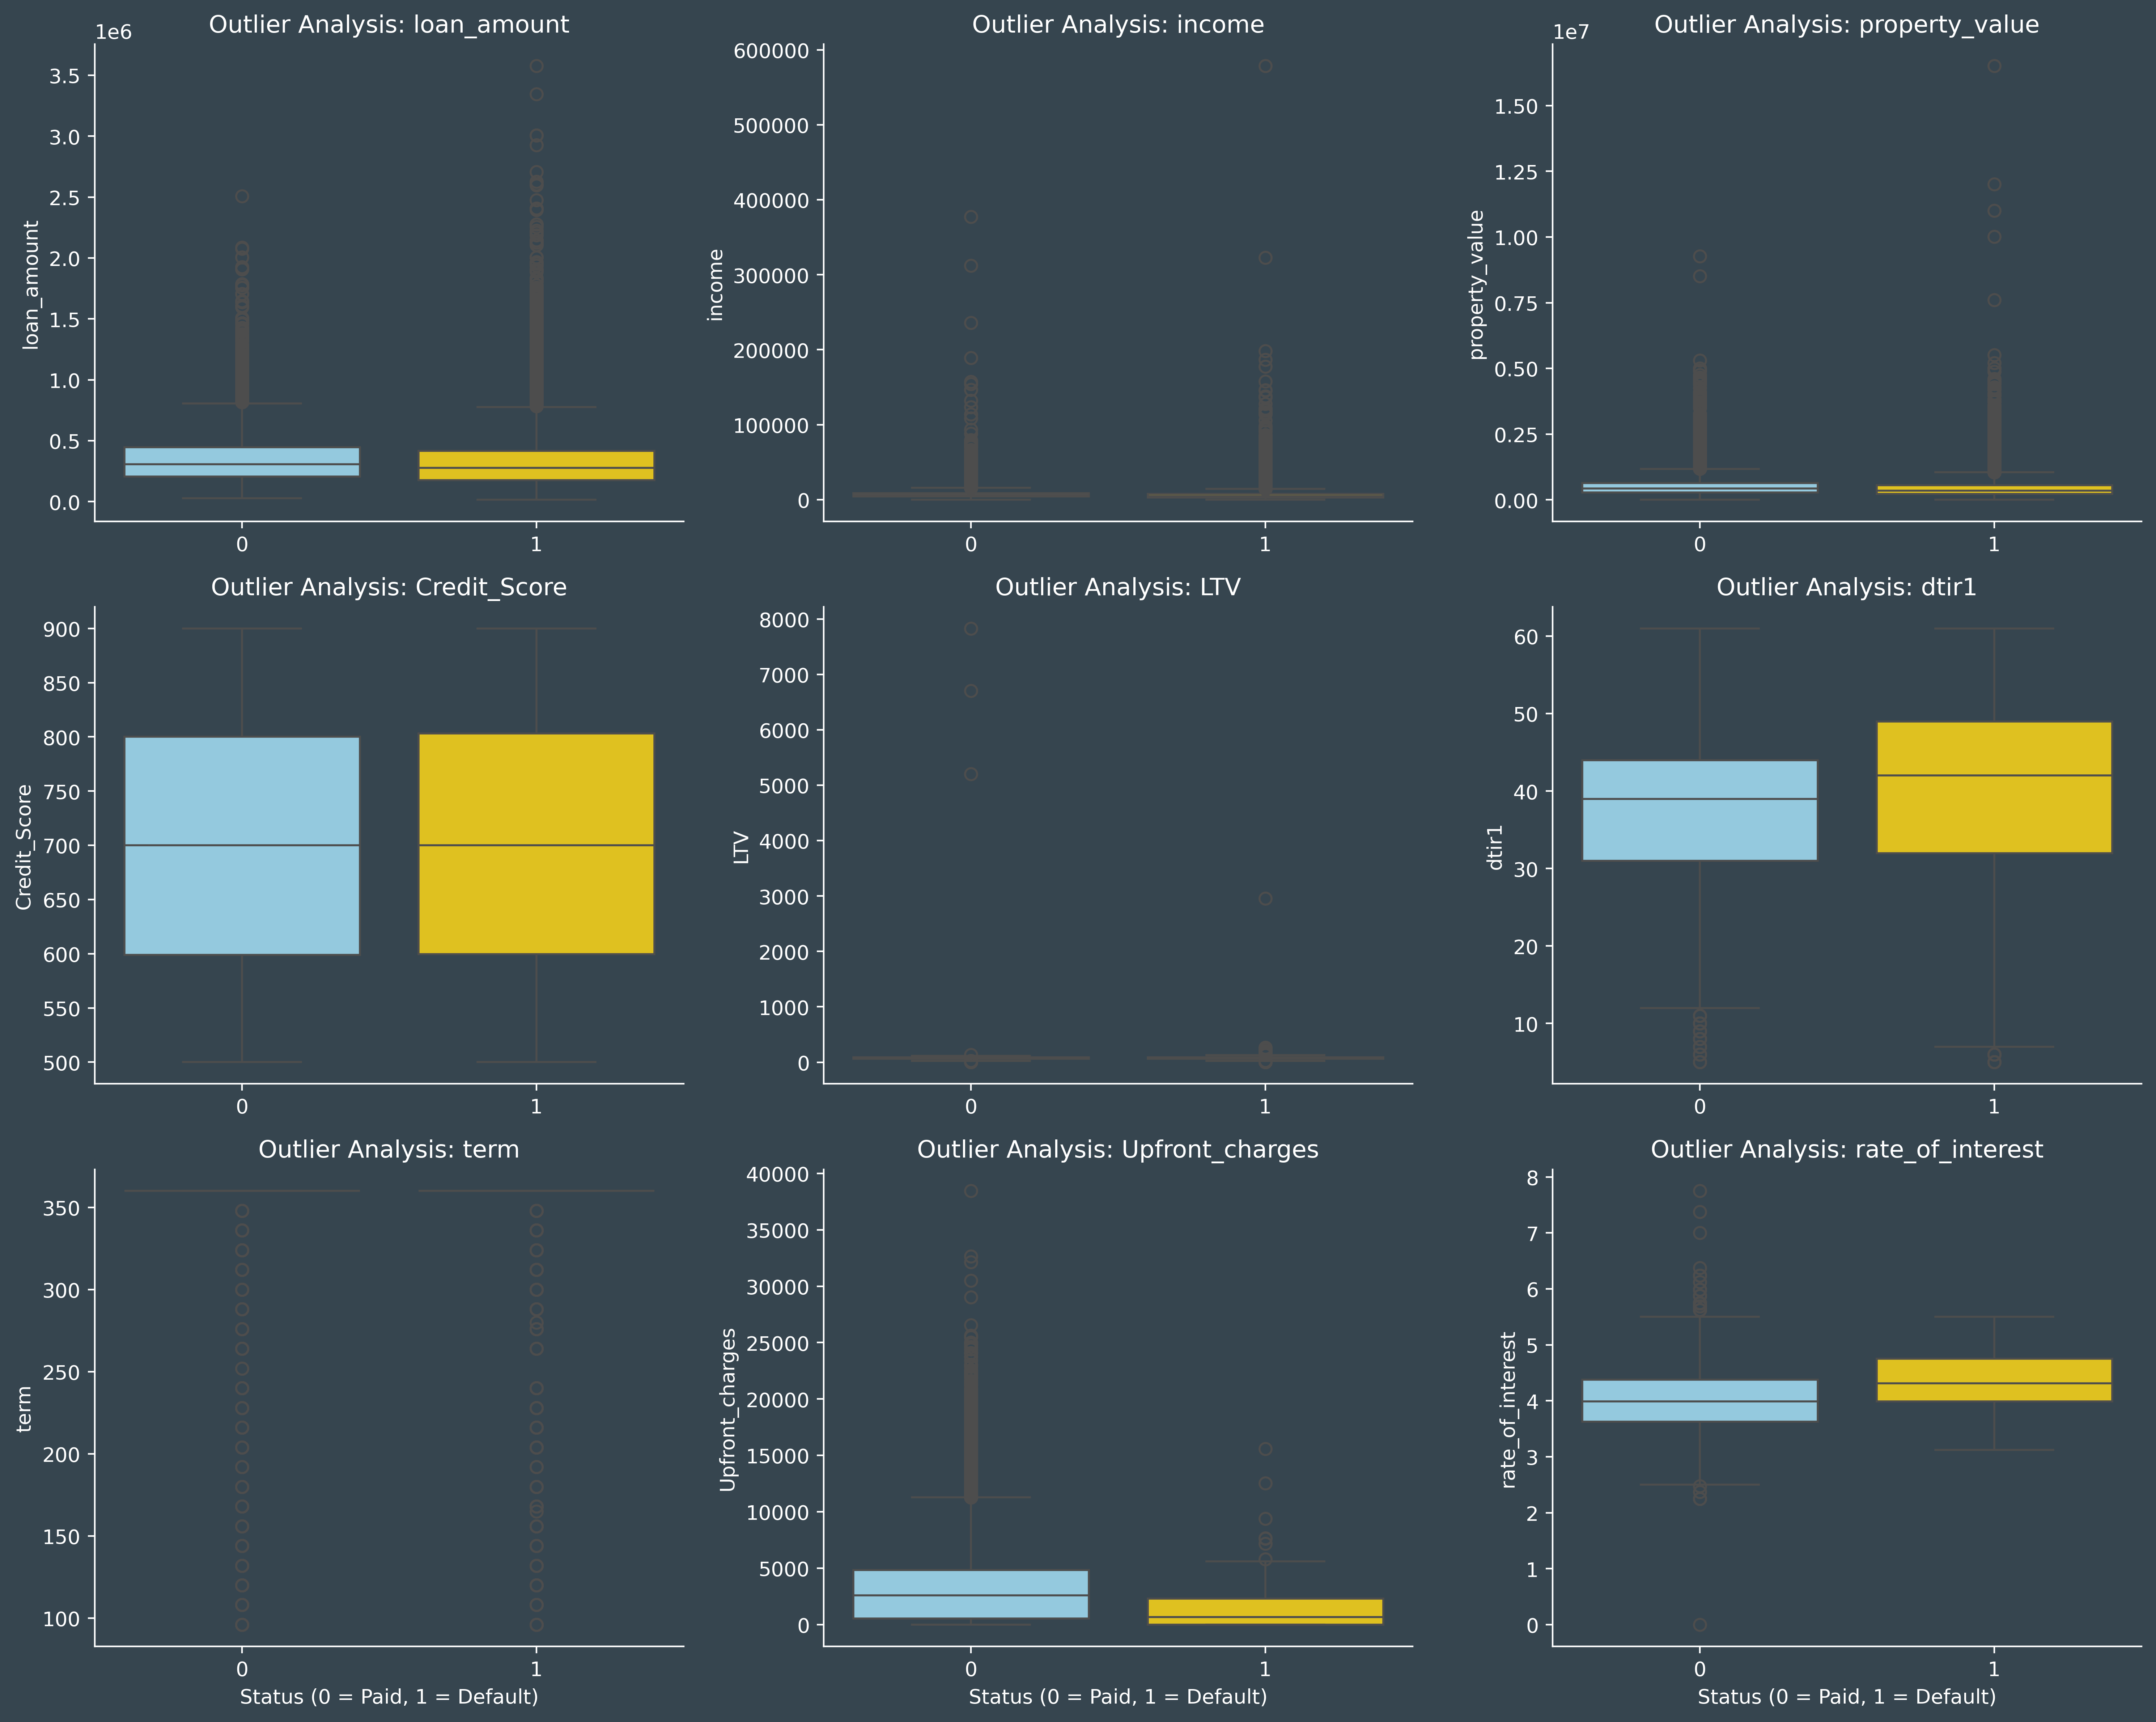

In [16]:
plt.style.use('dark_background')
fig, axes = plt.subplots(3, 3, figsize=(15, 12), dpi=400)
fig.patch.set_facecolor('#36454F')

for i, col in enumerate(numeric_cols):
    ax = axes[i // 3, i % 3]
    ax.set_facecolor('#36454F')
    sns.boxplot(x='Status', y=col, data=df, ax=ax, palette=['#87CEEB', '#FFD700'])
    ax.set_title(f'Outlier Analysis: {col}', color='white', fontsize=12)
    ax.set_xlabel('Status (0 = Paid, 1 = Default)' if i >= 6 else '', color='white')
    ax.set_ylabel(col, color='white')
    ax.tick_params(colors='white')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../reports/target_distribution_4.png', facecolor=fig.get_facecolor(), edgecolor='none')
plt.show()

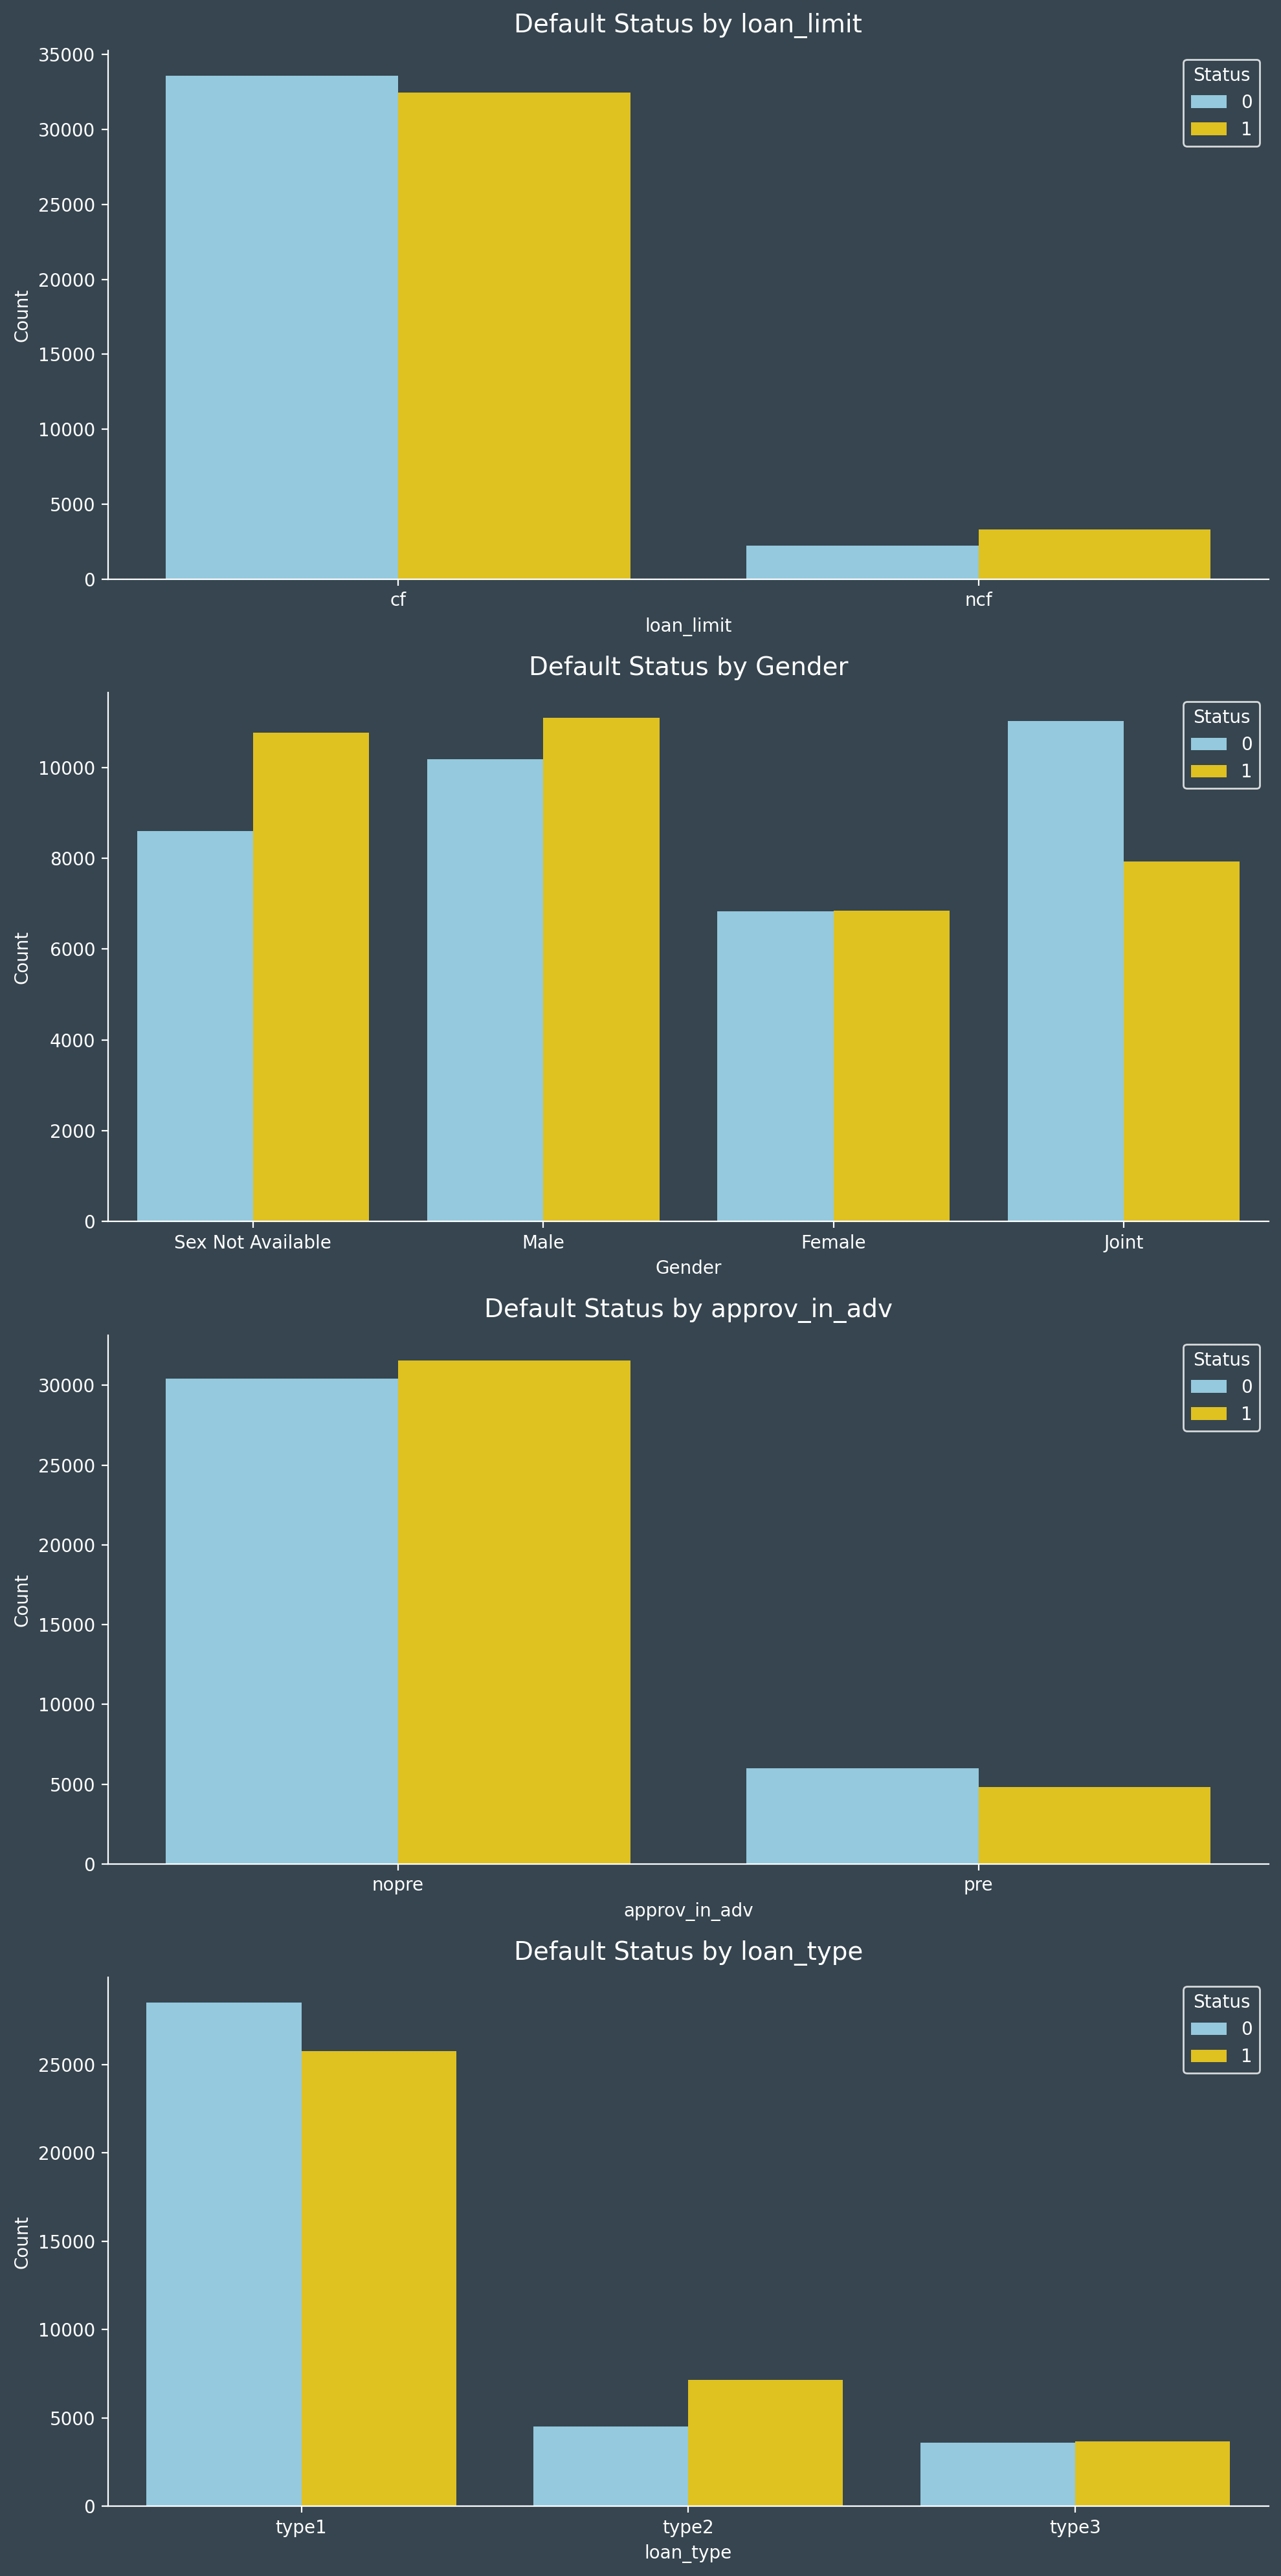

In [17]:
categorical_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns

if len(categorical_cols) > 0:
    cols_to_plot = categorical_cols[:4] 
    plt.style.use('dark_background')
    fig, axes = plt.subplots(len(cols_to_plot), 1, figsize=(10, 5 * len(cols_to_plot)), dpi=200)
    fig.patch.set_facecolor('#36454F')
    
    if len(cols_to_plot) == 1:
        axes = [axes]
    for i, col in enumerate(cols_to_plot):
        axes[i].set_facecolor('#36454F')
        sns.countplot(x=col, hue='Status', data=df, ax=axes[i], palette=['#87CEEB', '#FFD700'])
        axes[i].set_title(f'Default Status by {col}', color='white', fontsize=14, pad=10)
        axes[i].tick_params(axis='x', rotation=0, colors='white')
        axes[i].tick_params(axis='y', colors='white')
        axes[i].set_xlabel(col, color='white')
        axes[i].set_ylabel('Count', color='white')
        axes[i].legend(title='Status', facecolor='#36454F', edgecolor='white', loc='upper right')
        axes[i].spines['top'].set_visible(False)
        axes[i].spines['right'].set_visible(False)
        
    plt.tight_layout()
    plt.savefig('../reports/target_distribution_5.png', facecolor=fig.get_facecolor(), edgecolor='none')
    plt.show()
else:
    print("No categorical columns found.")

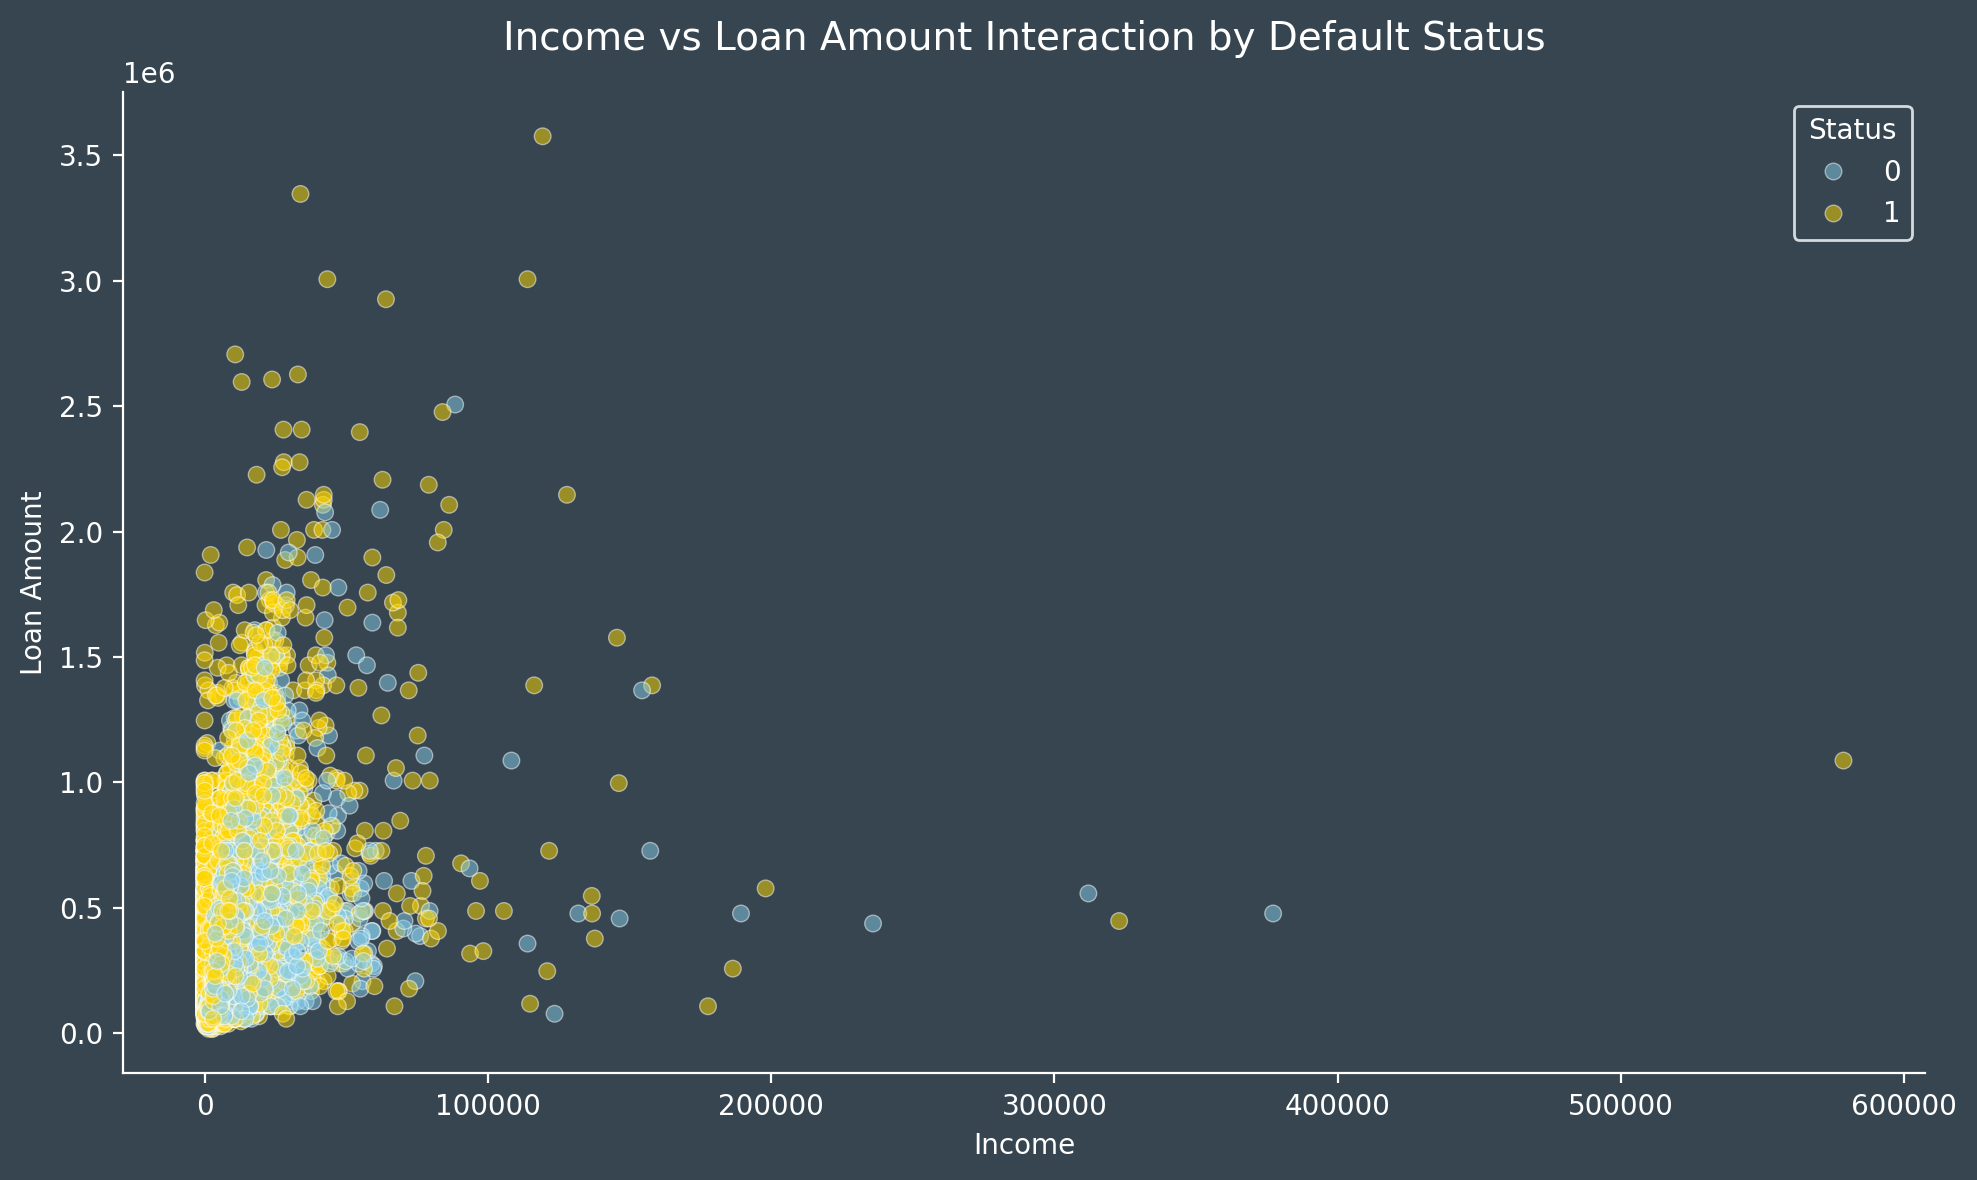

In [18]:
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(10, 6), dpi=200)
fig.patch.set_facecolor('#36454F')
ax.set_facecolor('#36454F')

sns.scatterplot(
    x='income', 
    y='loan_amount', 
    hue='Status', 
    data=df, 
    alpha=0.5, 
    palette=['#87CEEB', '#FFD700'], 
    ax=ax
)

plt.title('Income vs Loan Amount Interaction by Default Status', color='white', fontsize=14, pad=15)
ax.set_xlabel('Income', color='white')
ax.set_ylabel('Loan Amount', color='white')
ax.tick_params(colors='white')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

legend = ax.legend(title='Status', facecolor='#36454F', edgecolor='white')
plt.setp(legend.get_texts(), color='white')

plt.tight_layout()
plt.savefig('../reports/target_distribution_6.png', facecolor=fig.get_facecolor(), edgecolor='none')
plt.show()

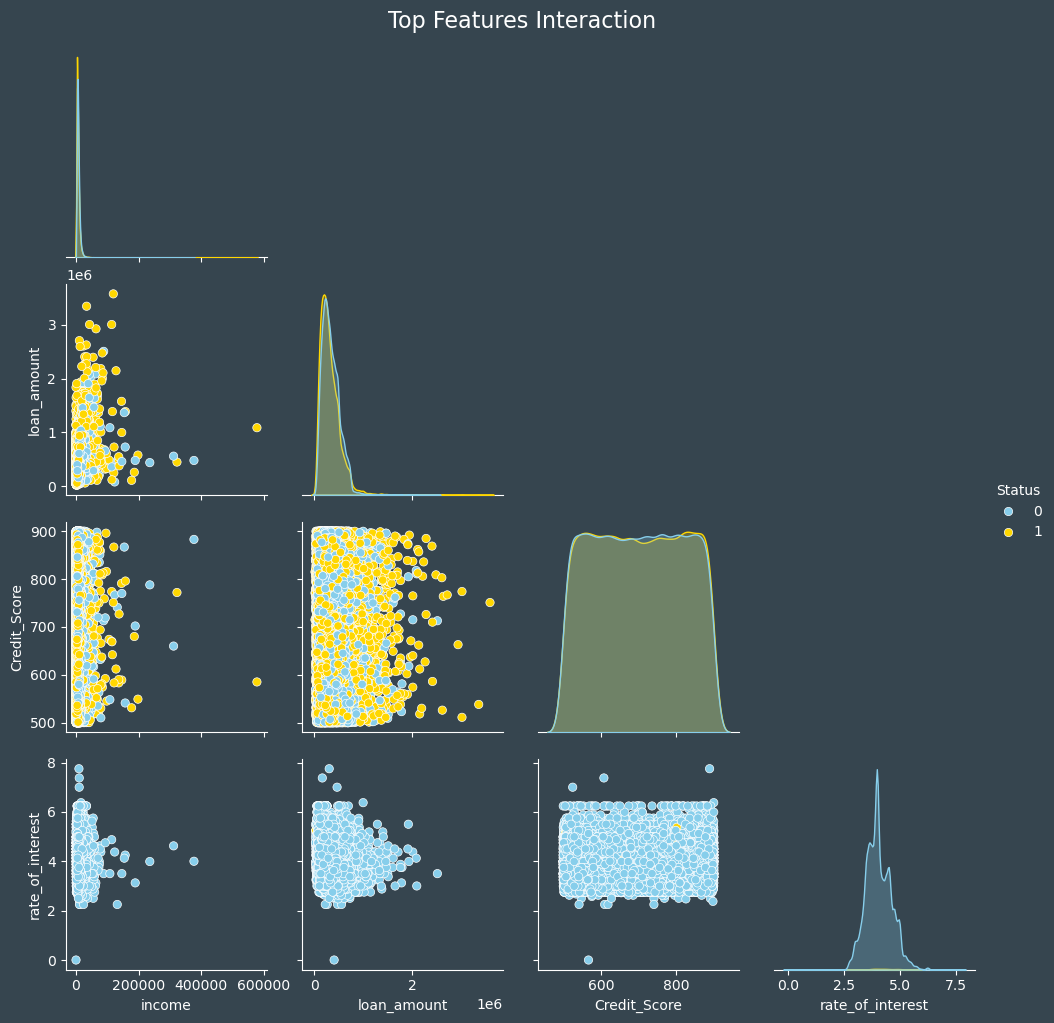

In [19]:
top_features = ['income', 'loan_amount', 'Credit_Score', 'rate_of_interest', 'Status']

pp = sns.pairplot(
    df[top_features], 
    hue='Status', 
    palette=['#87CEEB', '#FFD700'], 
    corner=True, 
    diag_kind='kde'
)

pp.fig.patch.set_facecolor('#36454F')
for ax in pp.axes.flatten():
    if ax is not None:
        ax.set_facecolor('#36454F')
        ax.tick_params(colors='white')
        ax.xaxis.label.set_color('white')
        ax.yaxis.label.set_color('white')

pp.fig.suptitle('Top Features Interaction', color='white', y=1.02, fontsize=16)

plt.savefig('../reports/target_distribution_7.png', facecolor=pp.fig.get_facecolor(), edgecolor='none')
plt.show()